In [1]:
library(data.table)
library(tidyr)
library(dplyr)
library(ggplot2)


Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




# Simulations

## No allel specific

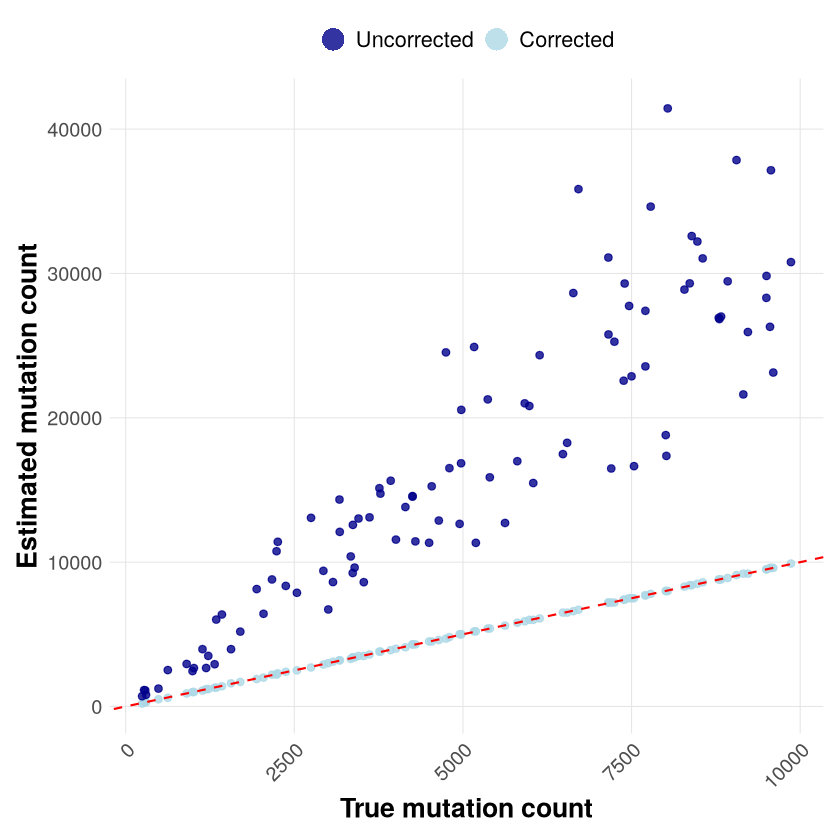

In [ ]:
set.seed(42)
 
Segment <- function() {
  base_rate <- runif(1, 1e-6, 100e-6)
  segment_size <- 1000000
  total_cn <- sample(3:6, 1)  
  timescale <- seq(0.01, 1, 0.01) 
  gain_timing <- sort(sample(seq(0.01, 0.99, 0.01), size = total_cn - 2, replace = FALSE),decreasing=F)
  mutations <- get_mutations(base_rate, segment_size, timescale, gain_timing, total_cn)
  mutation_multiplicity <- table(unlist(mutations$segments))  
  #estimated_mutation_rate <- sum(mutation_multiplicity) / (segment_size * total_cn * length(timescale))  
  #no_correction_mutation_rate <- mutations$n_mut/(segment_size * length(timescale))  
  estimated_mutation_rate <- sum(mutation_multiplicity) / total_cn 
  no_correction_mutation_rate <- mutations$n_mut  
  return(list(base_rate = base_rate*(segment_size * length(timescale)), 
              no_correction_rate = no_correction_mutation_rate,
              estimated_mutation_rate = estimated_mutation_rate, 
              total_cn = total_cn))
}
 
get_mutations <- function(base_rate, segment_size, timescale, gain_timing, total_cn)
{
  total_mut = 0
  segments <- list(integer(0), integer(0))
  current_gain_index <- 1  
  for (time_point in timescale)
  {
      for (i in seq_along(segments))
      {
     #n_mutations <- rpois(1, base_rate * segment_size)
          n_mutations <- round(base_rate * segment_size)
          total_mut = total_mut + n_mutations
          mutations <- sample(segment_size, n_mutations)
          segments[[i]] <- c(segments[[i]], mutations)
      }    
      if (current_gain_index <= length(gain_timing) && time_point >= gain_timing[current_gain_index])
      {
          random_segment_index <- sample(seq_along(segments), 1)
          segments <- c(segments, list(segments[[random_segment_index]]))
          current_gain_index <- current_gain_index + 1
      }
      
      l = lapply(segments, function(x) x[1])
      CN = lapply(l, function(v) sum(l == v))

  }  
  return(list(segments = segments,
              copyNumber = CN,
                 n_mut = total_mut))
}
 
rate_store <- data.frame(True_Rate = numeric(), Estimated_Rate = numeric(), Total_CN = integer())
 
for (i in 1:100) {
    s <- Segment() 
    rate_store <- rbind(rate_store, 
                        data.frame(True_Rate = s$base_rate, 
                                   No_Correction_Rate = s$no_correction_rate,
                                   Estimated_Rate = s$estimated_mutation_rate, 
                                   Total_CN = paste0("1-", s$total_cn)))
}
 

data_long = rbind(data.frame(True_Rate = rate_store$True_Rate,
                             Estimated_Rate = rate_store$Estimated_Rate,
                             Correction = "Corrected"),
                  data.frame(True_Rate = rate_store$True_Rate,
                             Estimated_Rate = rate_store$No_Correction_Rate,
                             Correction = "Uncorrected"))

# S'assurer que l'ordre du facteur est correct
data_long$Correction <- factor(data_long$Correction, 
                               levels = c("Uncorrected", "Corrected"))

# Plot corrigé
plot_toby <- ggplot(data_long, aes(x = True_Rate, y = Estimated_Rate, color = Correction)) +
  geom_point(size = 1.8, alpha = 0.8) +
  scale_color_manual(
    values = c("Uncorrected" = "darkblue",
               "Corrected" = "lightblue"),
    labels = c("Uncorrected", "Corrected")
  ) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", 
              color = "red", linewidth = 0.6) +
  labs(
    x = "True mutation count",
    y = "Estimated mutation count"
  ) +
  theme_minimal(base_size = 10) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
    legend.position = "top",
    legend.text = element_text(size = 13),
    legend.title = element_blank(),
    axis.title = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.margin = margin(10, 10, 10, 10)
  ) +
  guides(color = guide_legend(override.aes = list(size = 6, shape = 16)))

plot_toby


output_dir = "/srv/home/mlef0011/output/mutation_rate_project/SNV_quantification/accuracy/"
# ---- Sauvegarde PDF haute qualité ----
ggsave(
  filename = paste0(output_dir, "accuracy_SNV_count_correction.pdf"),
  plot = plot_toby,
  width = 6, height = 6, dpi = 600
)

ggsave(
  filename = paste0(output_dir, "accuracy_SNV_count_correction.png"),
  plot = plot_toby,
  width = 6, height = 6, dpi = 600
)

## Allele specific

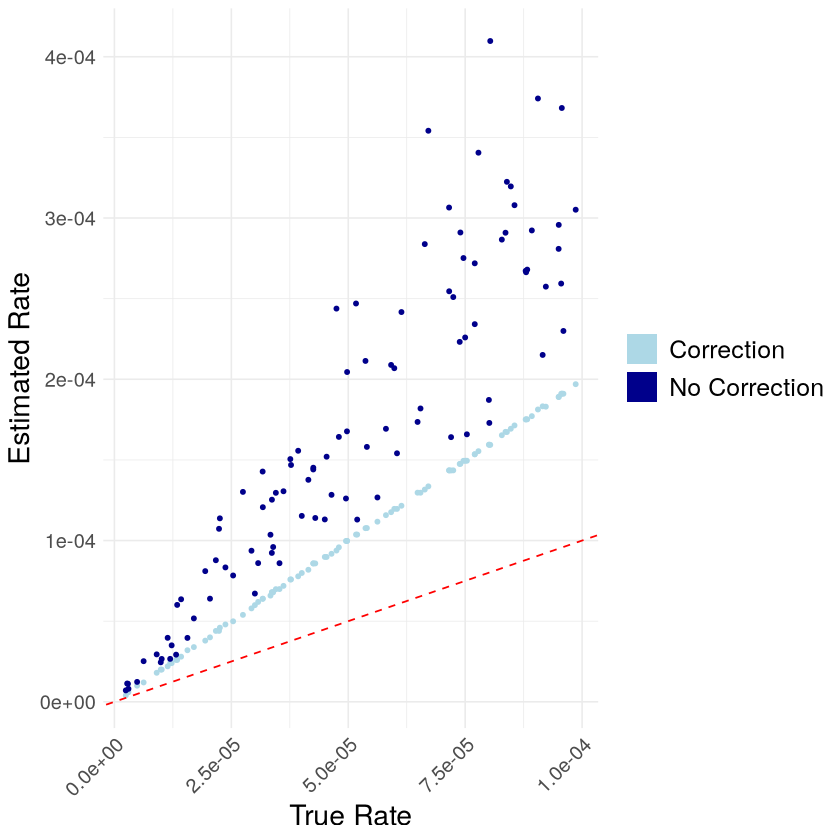

In [103]:
set.seed(42)
 
get_multiplicity_per_cn <- function(v, segments, copyNumber) {
  # indices des segments contenant v
  idx_cn <- which(sapply(segments, function(seg) v %in% seg))
  
  if (length(idx_cn) == 0) {
    return(data.frame(value = v, copyNumber = NA, multiplicity = 0))
  }
  
  # récupérer les copy numbers correspondants
  cn_vals <- copyNumber[idx_cn]
  
  # compter la multiplicité par copy number
  mult_table <- table(unlist(cn_vals))
  
  # transformer en data.frame propre
  df <- data.frame(
    value = v,
    copyNumber = as.numeric(names(mult_table)),
    multiplicity = as.integer(mult_table),
    stringsAsFactors = FALSE
  )
  
  return(df)
}
                         
Segment <- function() {
    base_rate <- runif(1, 1e-6, 100e-6)
    segment_size <- 1000000
    total_cn <- sample(3:6, 1)  
    timescale <- seq(0.01, 1, 0.01) 
    gain_timing <- sort(sample(seq(0.01, 0.99, 0.01), size = total_cn - 2, replace = FALSE),decreasing=F)
    mutations <- get_mutations(base_rate, segment_size, timescale, gain_timing, total_cn)
                             
    segments <- mutations$segments
    copyNumber <- mutations$copyNumber

    unique_vals <- unique(unlist(segments))

    result_list <- lapply(unique_vals, get_multiplicity_per_cn, segments = segments, copyNumber = copyNumber)
    result_df <- do.call(rbind, result_list)
                             
                             
    estimated_mutation_rate <- sum(result_df$multiplicity / result_df$copyNumber) / (segment_size * length(timescale))  
    no_correction_mutation_rate <- nrow(result_df)/(segment_size * length(timescale))  

  return(list(base_rate = base_rate, 
              no_correction_rate = no_correction_mutation_rate,
              estimated_mutation_rate = estimated_mutation_rate, 
              total_cn = total_cn))
}
 
get_mutations <- function(base_rate, segment_size, timescale, gain_timing, total_cn)
{
  total_mut = 0
  segments <- list(integer(0), integer(0))
  current_gain_index <- 1  
  for (time_point in timescale)
  {
      for (i in seq_along(segments))
      {
     #n_mutations <- rpois(1, base_rate * segment_size)
          n_mutations <- round(base_rate * segment_size)
          total_mut = total_mut + n_mutations
          mutations <- sample(segment_size, n_mutations)
          segments[[i]] <- c(segments[[i]], mutations)
      }    
      if (current_gain_index <= length(gain_timing) && time_point >= gain_timing[current_gain_index])
      {
          random_segment_index <- sample(seq_along(segments), 1)
          segments <- c(segments, list(segments[[random_segment_index]]))
          current_gain_index <- current_gain_index + 1
      }
      
      l = lapply(segments, function(x) x[1])
      CN = lapply(l, function(v) sum(l == v))

  }  
  return(list(segments = segments,
              copyNumber = CN,
                 n_mut = total_mut))
}
 
rate_store <- data.frame(True_Rate = numeric(), Estimated_Rate = numeric(), Total_CN = integer())
 
for (i in 1:100) {
    s <- Segment() 
    rate_store <- rbind(rate_store, 
                        data.frame(True_Rate = s$base_rate, 
                                   No_Correction_Rate = s$no_correction_rate,
                                   Estimated_Rate = s$estimated_mutation_rate, 
                                   Total_CN = paste0("1-", s$total_cn)))
}
 

data_long = rbind(data.frame(True_Rate = rate_store$True_Rate,
                             Estimated_Rate = rate_store$Estimated_Rate,
                             Correction = "Correction"),
                  data.frame(True_Rate = rate_store$True_Rate,
                             Estimated_Rate = rate_store$No_Correction_Rate,
                             Correction = "No Correction"))

plot_toby <- ggplot(data_long, aes(x = True_Rate, y = Estimated_Rate, color = factor(Correction))) +
    geom_point(size = 1) +  # Increase point size for better visibility in the plot
    scale_color_manual(values = c("lightblue", "darkblue")) +  # Specify lightblue and darkblue for the colors
    labs(x = "True Rate", y = "Estimated Rate") +
    theme_minimal(base_size = 10) +  # Set a larger base size for all elements
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
    theme(
        legend.text = element_text(size = 15),   # Legend text size
        legend.title = element_blank(),  # Remove the legend title
        axis.title = element_text(size = 17),    # Axis titles size
        axis.text = element_text(size = 12),     # Axis text size
        axis.text.x = element_text(angle = 45, hjust = 1)  # Diagonal X axis labels
    ) +
    guides(
        color = guide_legend(override.aes = list(size = 8, shape = 15))  # Larger and square points in the legend
    )

plot_toby

# PCAWG data

### no allele specific

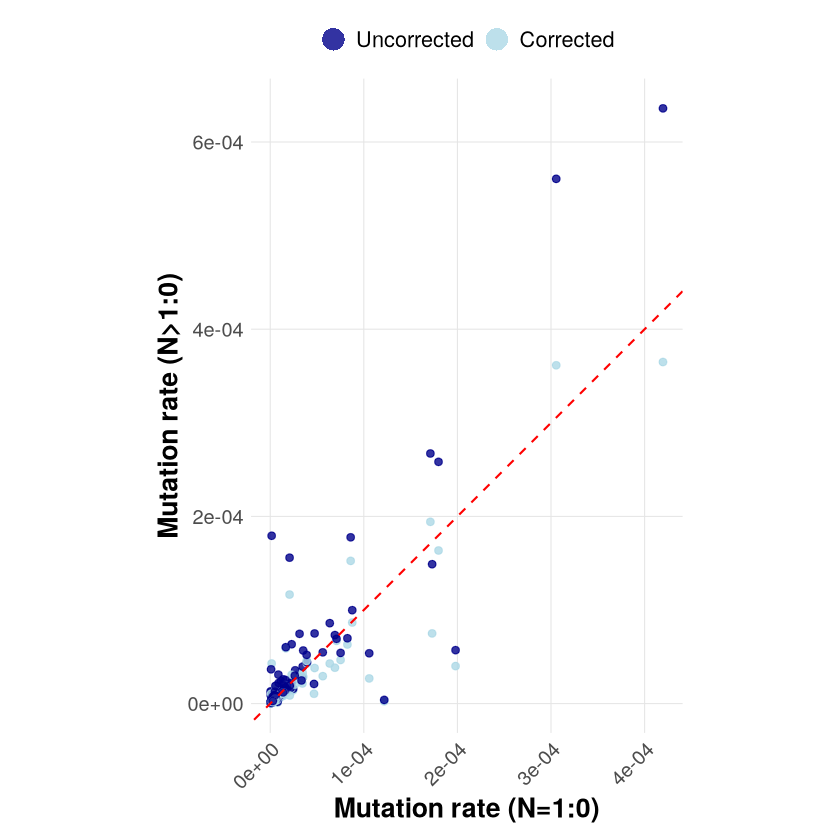

In [152]:
files <- list.files(path = "/srv/home/mlef0011/rawdata/PCAWG_data/TCGA/subclonal_reconstruction", full.names = TRUE)

res_samples = do.call(rbind, lapply(files, function(file) {
    sample <- gsub("_mutation_ccf.txt.gz", "", basename(file))
    
    snv <- fread(file, sep = "\t", header = TRUE)
    snv_loh <- subset(snv, minor_cn == 0)
    snv_loh$no_correction <- 1
    snv_loh$correction <- snv_loh$mult / snv_loh$major_cn
    
    # Vérifie qu'il y a bien des régions avec major_cn == 1 et > 1
    if (any(snv_loh$major_cn == 1) && any(snv_loh$major_cn > 1)) {
        
        cna_file <- paste0("/srv/home/mlef0011/rawdata/PCAWG_data/TCGA/cna/", sample, ".consensus.20170119.somatic.cna.txt")
        if (!file.exists(cna_file)) return(NULL)
        
        cna <- fread(cna_file, sep = "\t", header = TRUE)
        cna_loh <- subset(cna, minor_cn == 0 & minor_cn <=5)
        cna_loh$length <- cna_loh$end - cna_loh$start + 1
        
        n_mut_standard <- snv_loh[major_cn == 1, sum(no_correction, na.rm = TRUE)]
        n_mut_correction <- snv_loh[major_cn > 1, sum(correction, na.rm = TRUE)]
        n_mut_no_correction <- snv_loh[major_cn > 1, sum(no_correction, na.rm = TRUE)]
        
        length_cna_standard <- cna_loh[major_cn == 1, sum(length, na.rm = TRUE)]
        length_cna_correction <- cna_loh[major_cn > 1, sum(length, na.rm = TRUE)]
        length_cna_no_correction <- cna_loh[major_cn > 1, sum(length, na.rm = TRUE)]
        
        rate_mu_standard <- n_mut_standard / length_cna_standard
        rate_mu_correction <- n_mut_correction / length_cna_correction
        rate_mu_no_correction <- n_mut_no_correction / length_cna_no_correction
        
        return(data.frame(
            sample = sample,
            n_mut_standard = n_mut_standard,
            n_mut_correction = n_mut_correction,
            n_mut_no_correction = n_mut_no_correction,
            rate_mu_standard = rate_mu_standard,
            rate_mu_correction = rate_mu_correction,
            rate_mu_no_correction = rate_mu_no_correction
        ))
    } else {
        return(NULL)
    }
}))

res_samples_filt = res_samples[res_samples$n_mut_no_correction > 100 &  res_samples$n_mut_standard > 100,]


# Transformer le dataframe en format long
res_long <- res_samples_filt %>%
  pivot_longer(
    cols = c(rate_mu_correction, rate_mu_no_correction),
    names_to = "Correction",
    values_to = "Estimated_Rate"
  )

# Définir le facteur avec le bon ordre
res_long$Correction <- factor(
  res_long$Correction,
  levels = c("rate_mu_no_correction", "rate_mu_correction"),
  labels = c("Uncorrected", "Corrected")
)

# Plot corrigé
plot_no_al_sp <- ggplot(res_long, aes(x = rate_mu_standard, y = Estimated_Rate, color = Correction)) +
  geom_point(size = 1.8, alpha = 0.8) +
  scale_color_manual(
    values = c("Uncorrected" = "darkblue",
               "Corrected" = "lightblue"),
    labels = c("Uncorrected", "Corrected")
  ) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", 
              color = "red", linewidth = 0.6) +

  labs(
    x = "Mutation rate (N=1:0)",
    y = "Mutation rate (N>1:0)"
  ) +
  theme_minimal(base_size = 10) +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
    legend.position = "top",
    legend.text = element_text(size = 13),
    legend.title = element_blank(),
    axis.title = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.margin = margin(10, 10, 10, 10)
  ) +
  guides(color = guide_legend(override.aes = list(size = 6, shape = 16))) +
  coord_equal()

plot_no_al_sp

ggsave(
  filename = paste0(output_dir, "accuracy_SNV_count_correction_no_allele_specific.pdf"),
  plot = plot_no_al_sp,
  width = 6, height = 6, dpi = 600
)

ggsave(
  filename = paste0(output_dir, "accuracy_SNV_count_correction_no_allele_specific.png"),
  plot = plot_no_al_sp,
  width = 6, height = 6, dpi = 600
)



### allele specific
On prend les semgent 1:X (X>1) et on compare les mutations sur les 2 copies. La copie ayant CN=1 est la copie de référence pour le mutation rate. On calcule le mutation rate corrigé et non corrigé sur l'autre copie (la copie avec X > 1) et on copare avec le tmutation rate standar de la copie N = 1.

In [145]:
get_quantification <- function(n_copy, files) {
  results <- lapply(files, function(file) {
    sample = gsub("SNV_quantification_","",gsub(".txt","",basename(file)))
    data <- fread(file, header = TRUE, data.table = FALSE)
    
    # Sous-ensemble des SNVs pertinents
    sub <- subset(data, minor_cn == 1 & major_cn == n_copy)
    
    if (nrow(sub) > 0) {
      gain_subset <- subset(sub, gain_copy == TRUE)
      no_gain_subset <- subset(sub, is.na(gain_copy) | gain_copy != TRUE)
      
      gain_no_correction <- nrow(gain_subset)
      gain_correction <- sum(as.numeric(gain_subset$mult/gain_subset$major_cn), na.rm = TRUE)
      no_gain <- nrow(no_gain_subset)
      
      return(c(sample, n_copy, gain_no_correction, gain_correction, no_gain))
    } else {
      return(c(sample, n_copy, NA, NA, NA))
    }
  })
  
  results <- do.call(rbind, results)
  colnames(results) <- c("sample", "major_CN", "gain_no_correction", "gain_correction", "no_gain")
  return(results)
}


Warning message:
"Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`)."


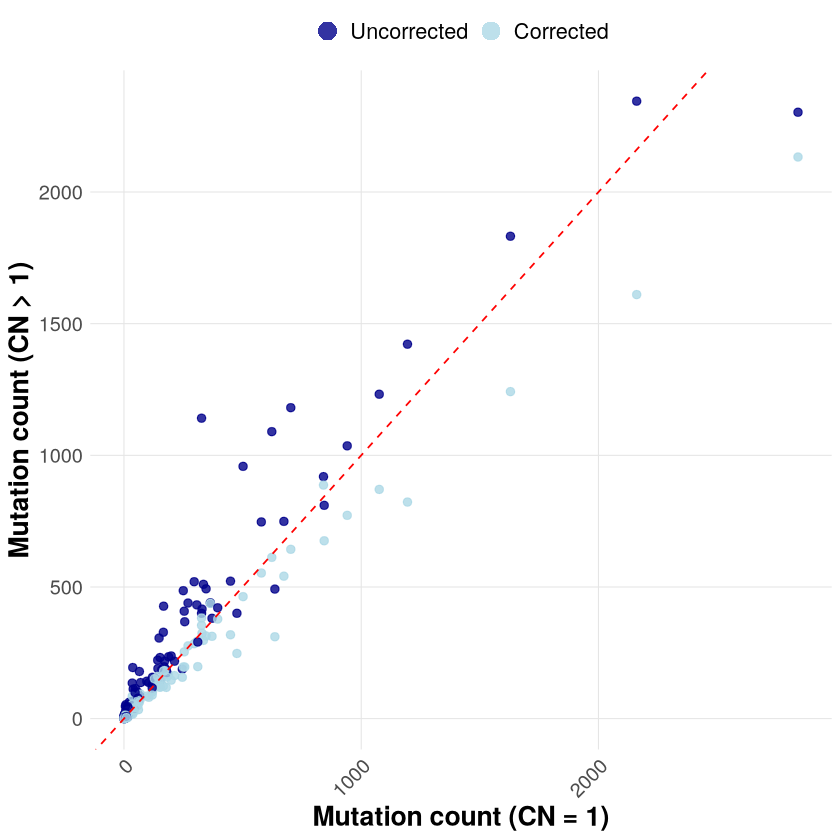

Warning message:
"Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`)."


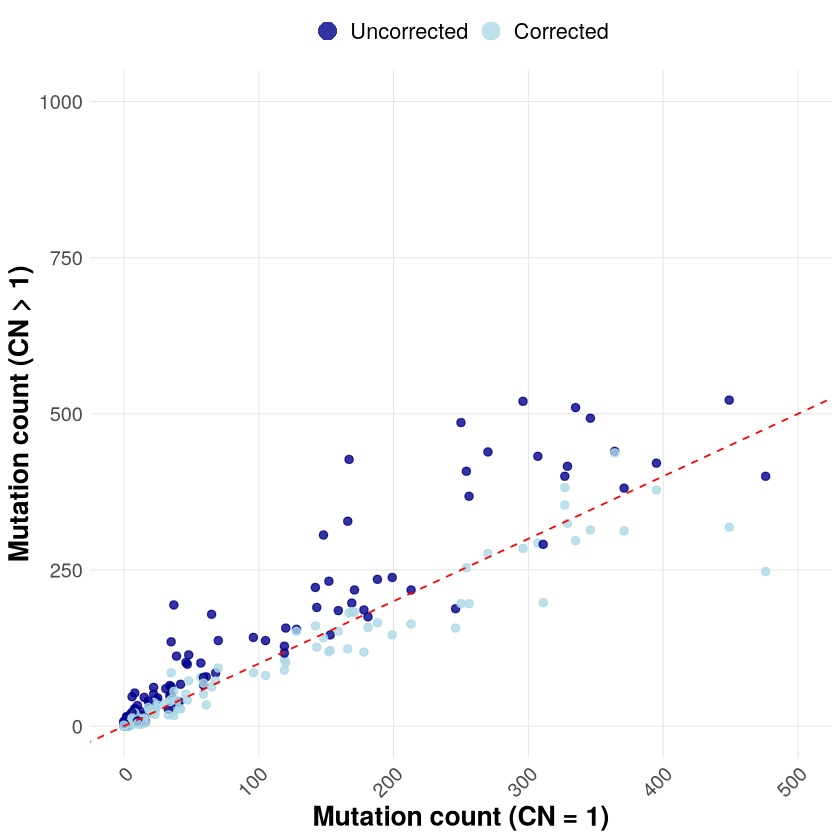

In [150]:
info_ma = read.table("/srv/home/mlef0011/output/mutation_rate_project/prediction_PCAWG_no_AMR/input_paths_mixed_ancestry_PCAWG_100000SNPs.tsv", header=T)
samples = info_ma$sample
files <- paste0("/srv/home/mlef0011/output/mutation_rate_project/SNV_quantification/",samples,"/SNV_quantification_",samples,".txt")
files <- files[file.exists(files)]
major_cn_vec = 2:5
assess_correction = as.data.frame(do.call(rbind,lapply(major_cn_vec, function(x) get_quantification(x,files))))
assess_correction <- na.omit(assess_correction)
assess_correction <- assess_correction %>%
  mutate(
    gain_no_correction = as.numeric(gain_no_correction),
    gain_correction = as.numeric(gain_correction),
    no_gain = as.numeric(no_gain)
  )

df_long <- assess_correction %>%
  pivot_longer(
    cols = c(gain_no_correction, gain_correction),
    names_to = "Correction",
    values_to = "Gain")
                                                       
df_long$Correction <- factor(
  df_long$Correction,
  levels = c("gain_no_correction", "gain_correction"),
  labels = c("Uncorrected", "Corrected")
)
      
                                                       
plot_gain <- ggplot(df_long, aes(x = no_gain, y = Gain, color = Correction)) +
  geom_point(size = 2, alpha = 0.8) +
  scale_color_manual(
    values = c("Uncorrected" = "darkblue",
               "Corrected" = "lightblue"),
    labels = c("Uncorrected", "Corrected")
  ) +
  labs(
    x = "Mutation count (CN = 1)",
    y = "Mutation count (CN > 1)",
    color = NULL
  ) +
  theme_minimal(base_size = 10) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  theme(
    legend.position = "top",
    legend.text = element_text(size = 13),
    axis.title = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.3)
  ) +
  guides(color = guide_legend(override.aes = list(size = 5, shape = 16))) 

plot_gain
         
                                                       
plot_gain_zoom <- ggplot(df_long, aes(x = no_gain, y = Gain, color = Correction)) +
  geom_point(size = 2, alpha = 0.8) +
  scale_color_manual(
    values = c("Uncorrected" = "darkblue",
               "Corrected" = "lightblue"),
    labels = c("Uncorrected", "Corrected")
  ) +
  labs(
    x = "Mutation count (CN = 1)",
    y = "Mutation count (CN > 1)",
    color = NULL
  ) +
  theme_minimal(base_size = 10) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  xlim(0,500) +
  ylim(0,1000) +
  theme(
    legend.position = "top",
    legend.text = element_text(size = 13),
    axis.title = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.3)
  ) +
  guides(color = guide_legend(override.aes = list(size = 5, shape = 16))) 

plot_gain_zoom
                   
                                                       
                                                       
ggsave(
  filename = paste0(output_dir, "accuracy_SNV_count_correction_allele_specific.pdf"),
  plot = plot_gain,
  width = 6, height = 6, dpi = 600
)

ggsave(
  filename = paste0(output_dir, "accuracy_SNV_count_correction_allele_specific.png"),
  plot = plot_gain,
  width = 6, height = 6, dpi = 600
)

                                                       
ggsave(
  filename = paste0(output_dir, "accuracy_SNV_count_correction_allele_specific_zoom.pdf"),
  plot = plot_gain_zoom,
  width = 6, height = 6, dpi = 600
)

ggsave(
  filename = paste0(output_dir, "accuracy_SNV_count_correction_allele_specific_zoom.png"),
  plot = plot_gain_zoom,
  width = 6, height = 6, dpi = 600
)